In [2]:

# Cell 1: Import libraries

from pathlib import Path
import json

import pandas as pd
import matplotlib.pyplot as plt


In [3]:
from pathlib import Path

current_dir = Path.cwd()
print(current_dir)

/Users/tranquangtrong/Desktop/cifake-image-classification-explainable-ai/notebooks


In [5]:

# Cell 2: Define paths and metric files

from pathlib import Path

current_dir = Path.cwd()

# Detect project root automatically
if (current_dir / "outputs" / "metrics").exists():
    PROJECT_ROOT = current_dir
elif (current_dir.parent / "outputs" / "metrics").exists():
    PROJECT_ROOT = current_dir.parent
else:
    raise FileNotFoundError(
        "Cannot find outputs/metrics. Please run this notebook from the project root "
        "or from the notebooks/ directory."
    )

METRICS_DIR = PROJECT_ROOT / "outputs" / "metrics"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures" / "training_behavior"
ANALYSIS_DIR = PROJECT_ROOT / "outputs" / "analysis"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

model_files = {
    "SimpleCNN": METRICS_DIR / "simple_cnn_metrics.json",
    "ResNet18": METRICS_DIR / "resnet18_metrics.json",
    "EfficientNet-B0": METRICS_DIR / "efficientnet_b0_metrics.json",
    "DenseNet121": METRICS_DIR / "densenet121_metrics.json",
    "DeiT-Tiny": METRICS_DIR / "deit_tiny_metrics.json",
}

print("Project root:", PROJECT_ROOT)
print("Metrics directory:", METRICS_DIR)
print("Figures directory:", FIGURES_DIR)
print()

for model_name, path in model_files.items():
    print(f"{model_name}: {path.name} -> exists = {path.exists()}")


Project root: /Users/tranquangtrong/Desktop/cifake-image-classification-explainable-ai
Metrics directory: /Users/tranquangtrong/Desktop/cifake-image-classification-explainable-ai/outputs/metrics
Figures directory: /Users/tranquangtrong/Desktop/cifake-image-classification-explainable-ai/outputs/figures/training_behavior

SimpleCNN: simple_cnn_metrics.json -> exists = True
ResNet18: resnet18_metrics.json -> exists = True
EfficientNet-B0: efficientnet_b0_metrics.json -> exists = True
DenseNet121: densenet121_metrics.json -> exists = True
DeiT-Tiny: deit_tiny_metrics.json -> exists = True


In [7]:

# Cell 3: Load each model history separately

metrics_data = {}
history_by_model = {}
metadata_rows = []

for model_name, json_path in model_files.items():
    with open(json_path, "r") as f:
        data = json.load(f)

    metrics_data[model_name] = data

    history_rows = []

    for item in data["history"]:
        epoch = item["epoch"]
        train = item["train"]
        val = item["validation"]

        history_rows.append({
            "epoch": epoch,

            "train_loss": train["loss"],
            "train_accuracy": train["accuracy"],
            "train_precision": train["precision"],
            "train_recall": train["recall"],
            "train_f1": train["f1"],

            "val_loss": val["loss"],
            "val_accuracy": val["accuracy"],
            "val_precision": val["precision"],
            "val_recall": val["recall"],
            "val_f1": val["f1"],
        })

    history_by_model[model_name] = pd.DataFrame(history_rows)

    metadata_rows.append({
        "model": model_name,
        "checkpoint_path": data["checkpoint_path"],
        "best_epoch": data["best_epoch"],
        "batch_size": data["batch_size"],
        "learning_rate": data["learning_rate"],
        "weight_decay": data.get("weight_decay", None),
        "max_epochs": data["max_epochs"],
        "patience": data["early_stopping_patience"],
        "val_ratio": data["val_ratio"],
        "seed": data["seed"],
        "device": data["device"],
        "final_epoch": data["history"][-1]["epoch"],

        "best_val_loss": data["best_validation_metrics"]["loss"],
        "best_val_accuracy": data["best_validation_metrics"]["accuracy"],
        "best_val_f1": data["best_validation_metrics"]["f1"],

        "test_loss": data["final_test_metrics"]["loss"],
        "test_accuracy": data["final_test_metrics"]["accuracy"],
        "test_precision": data["final_test_metrics"]["precision"],
        "test_recall": data["final_test_metrics"]["recall"],
        "test_f1": data["final_test_metrics"]["f1"],
    })

metadata_df = pd.DataFrame(metadata_rows)

print("Loaded models:")
for model_name in history_by_model.keys():
    print(f"- {model_name}: {len(history_by_model[model_name])} epochs")

display(metadata_df)



Loaded models:
- SimpleCNN: 14 epochs
- ResNet18: 14 epochs
- EfficientNet-B0: 14 epochs
- DenseNet121: 15 epochs
- DeiT-Tiny: 30 epochs


,model,checkpoint_path,best_epoch,batch_size,learning_rate,weight_decay,max_epochs,patience,val_ratio,seed,device,final_epoch,best_val_loss,best_val_accuracy,best_val_f1,test_loss,test_accuracy,test_precision,test_recall,test_f1
0,SimpleCNN,outputs/checkpoints/simple_cnn_best_model.pt,9,64,0.0010,NaN,50,5,0.2,42,mps,14,0.150160,0.94345,0.942974,0.150262,0.94265,0.953117,0.9311,0.941980
1,ResNet18,outputs/checkpoints/resnet18_best_model.pt,9,64,0.0010,NaN,50,5,0.2,42,mps,14,0.136928,0.95060,0.951200,0.137099,0.94800,0.941902,0.9549,0.948356
2,EfficientNet-B0,outputs/checkpoints/efficientnet_b0_best_model.pt,9,64,0.0010,NaN,50,5,0.2,42,mps,14,0.134724,0.94785,0.947931,0.129921,0.94955,0.950045,0.9490,0.949522
3,DenseNet121,outputs/checkpoints/densenet121_best_model.pt,10,64,0.0010,NaN,50,5,0.2,42,mps,15,0.140535,0.95130,0.951730,0.136493,0.95120,0.944007,0.9593,0.951592
4,DeiT-Tiny,outputs/checkpoints/deit_tiny_best_model.pt,22,32,0.0003,0.05,30,8,0.2,42,mps,30,0.342721,0.86000,0.862933,0.336656,0.86115,0.848701,0.8790,0.863585


In [8]:

# Cell 3.1: View one model history

model_name = "DenseNet121"

display(history_by_model[model_name])



,epoch,train_loss,train_accuracy,train_precision,train_recall,train_f1,val_loss,val_accuracy,val_precision,val_recall,val_f1
0,1,0.271402,0.885813,0.885706,0.885950,0.885828,0.285884,0.88240,0.895041,0.8664,0.880488
1,2,0.189090,0.925913,0.926392,0.925350,0.925871,0.190129,0.92355,0.899764,0.9533,0.925759
2,3,0.162458,0.936300,0.936518,0.936050,0.936284,0.175537,0.93220,0.907121,0.9630,0.934226
3,4,0.143398,0.944575,0.944175,0.945025,0.944600,0.173978,0.93235,0.958727,0.9036,0.930347
4,5,0.126163,0.951700,0.952379,0.950950,0.951664,0.184890,0.92750,0.910742,0.9479,0.928949
5,6,0.111230,0.956500,0.957186,0.955750,0.956467,0.149198,0.94045,0.936478,0.9450,0.940720
6,7,0.098377,0.962350,0.962489,0.962200,0.962344,0.148627,0.94445,0.921719,0.9714,0.945908
7,8,0.084973,0.967775,0.967144,0.968450,0.967797,0.152975,0.94125,0.953355,0.9279,0.940455
8,9,0.075072,0.970825,0.970566,0.971100,0.970833,0.187230,0.93265,0.897912,0.9763,0.935467
9,10,0.062646,0.976413,0.976139,0.976700,0.976419,0.140535,0.95130,0.943407,0.9602,0.951730


In [9]:

# Cell 4: Plot training curves for one selected model

def plot_single_model_training_curves(model_name):
    if model_name not in history_by_model:
        raise ValueError(f"Model not found: {model_name}")

    df = history_by_model[model_name]

    best_epoch = metrics_data[model_name]["best_epoch"]

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    plot_items = [
        ("loss", "Loss"),
        ("accuracy", "Accuracy"),
        ("f1", "F1-score"),
    ]

    for ax, (metric_key, metric_title) in zip(axes, plot_items):
        ax.plot(
            df["epoch"],
            df[f"train_{metric_key}"],
            marker="o",
            label="Train",
        )

        ax.plot(
            df["epoch"],
            df[f"val_{metric_key}"],
            marker="o",
            label="Validation",
        )

        ax.axvline(
            best_epoch,
            linestyle="--",
            label=f"Best epoch {best_epoch}",
        )

        ax.set_title(f"{model_name}: {metric_title}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel(metric_title)
        ax.grid(True, alpha=0.3)
        ax.legend()

    fig.suptitle(f"{model_name} Training Behavior", fontsize=14)
    fig.tight_layout()

    safe_model_name = (
        model_name.lower()
        .replace("-", "_")
        .replace(" ", "_")
    )

    output_path = FIGURES_DIR / f"{safe_model_name}_training_curves.png"
    fig.savefig(output_path, dpi=300, bbox_inches="tight")

    plt.show()

    print(f"Saved figure to: {output_path}")




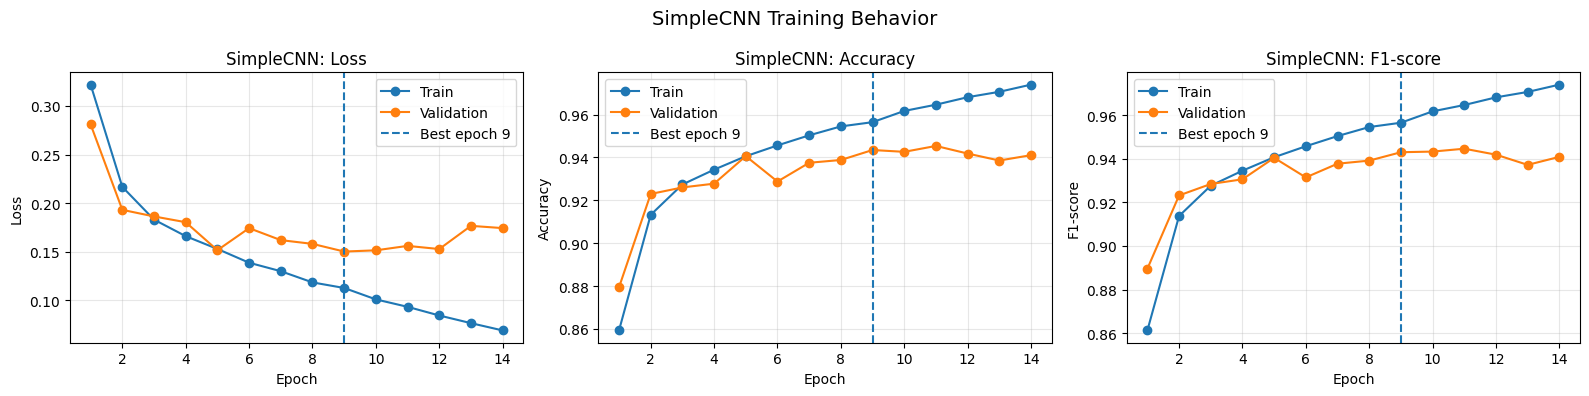

Saved figure to: /Users/tranquangtrong/Desktop/cifake-image-classification-explainable-ai/outputs/figures/training_behavior/simplecnn_training_curves.png


In [10]:
plot_single_model_training_curves("SimpleCNN")

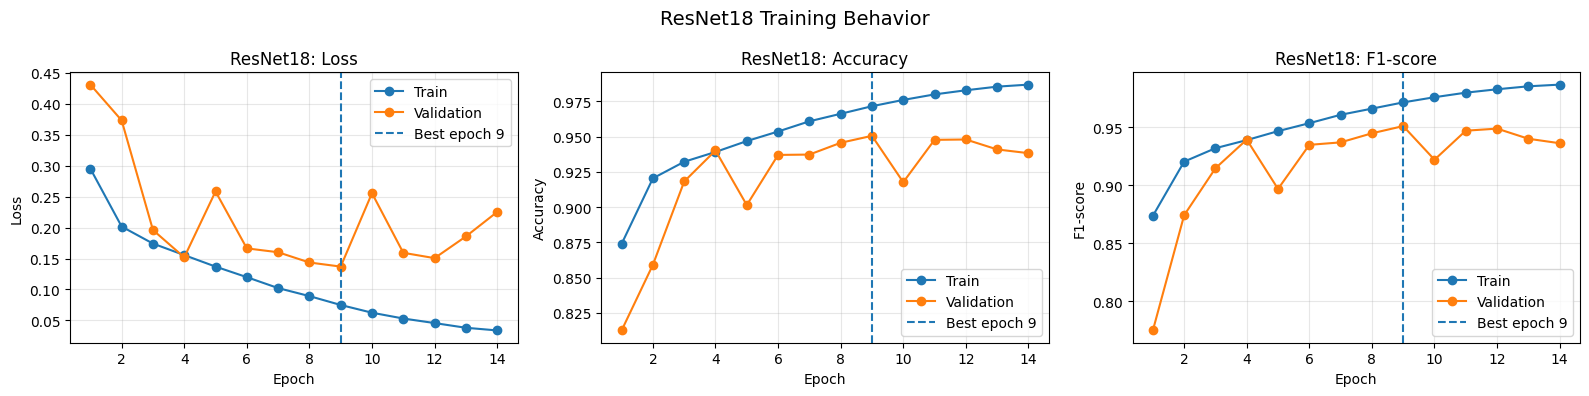

Saved figure to: /Users/tranquangtrong/Desktop/cifake-image-classification-explainable-ai/outputs/figures/training_behavior/resnet18_training_curves.png


In [11]:
plot_single_model_training_curves("ResNet18")

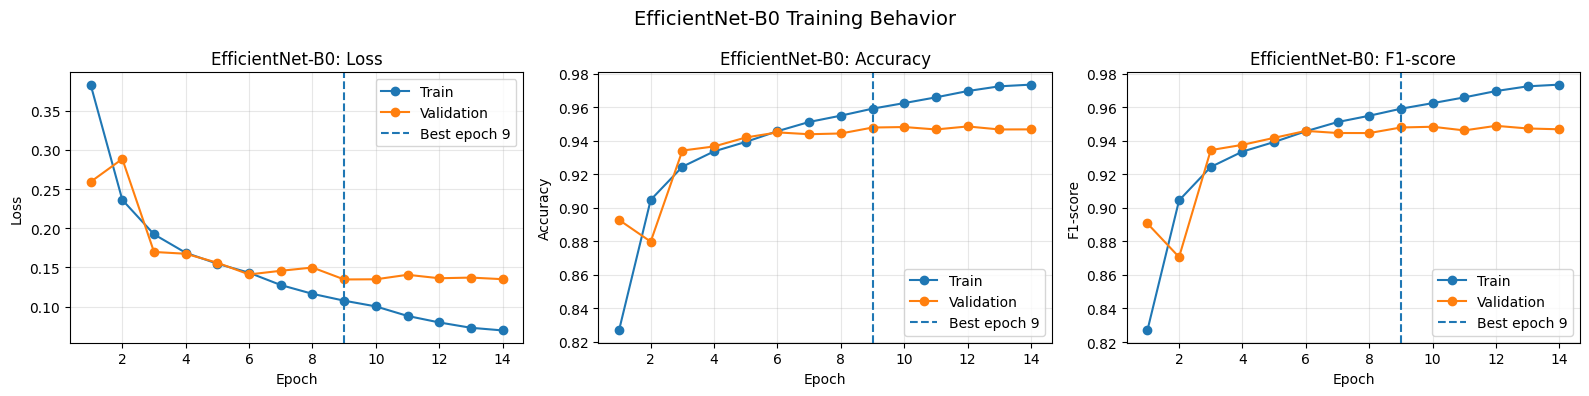

Saved figure to: /Users/tranquangtrong/Desktop/cifake-image-classification-explainable-ai/outputs/figures/training_behavior/efficientnet_b0_training_curves.png


In [12]:

plot_single_model_training_curves("EfficientNet-B0")


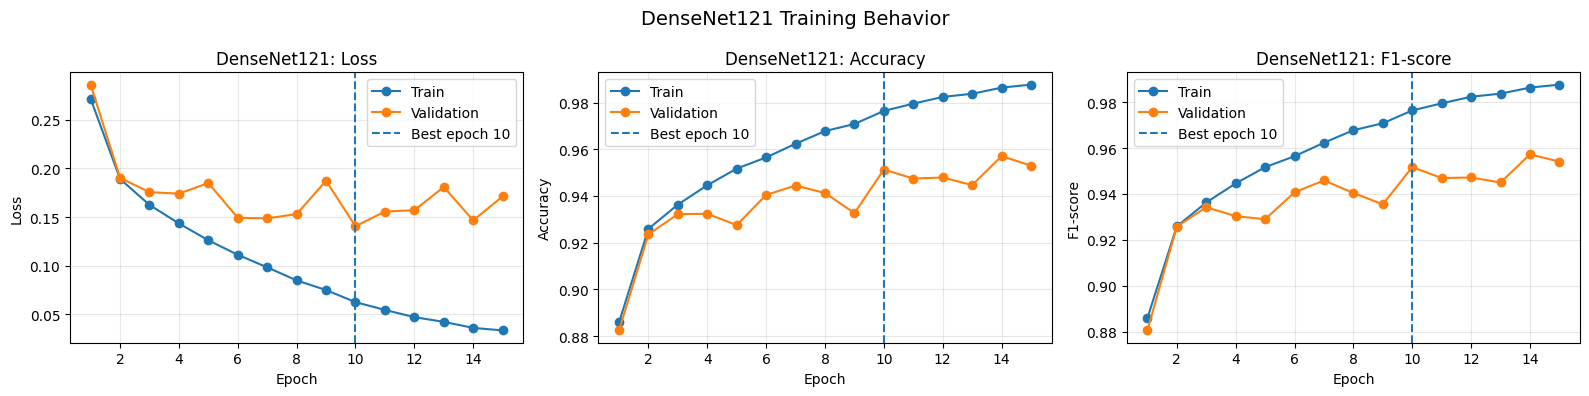

Saved figure to: /Users/tranquangtrong/Desktop/cifake-image-classification-explainable-ai/outputs/figures/training_behavior/densenet121_training_curves.png


In [14]:
plot_single_model_training_curves("DenseNet121")

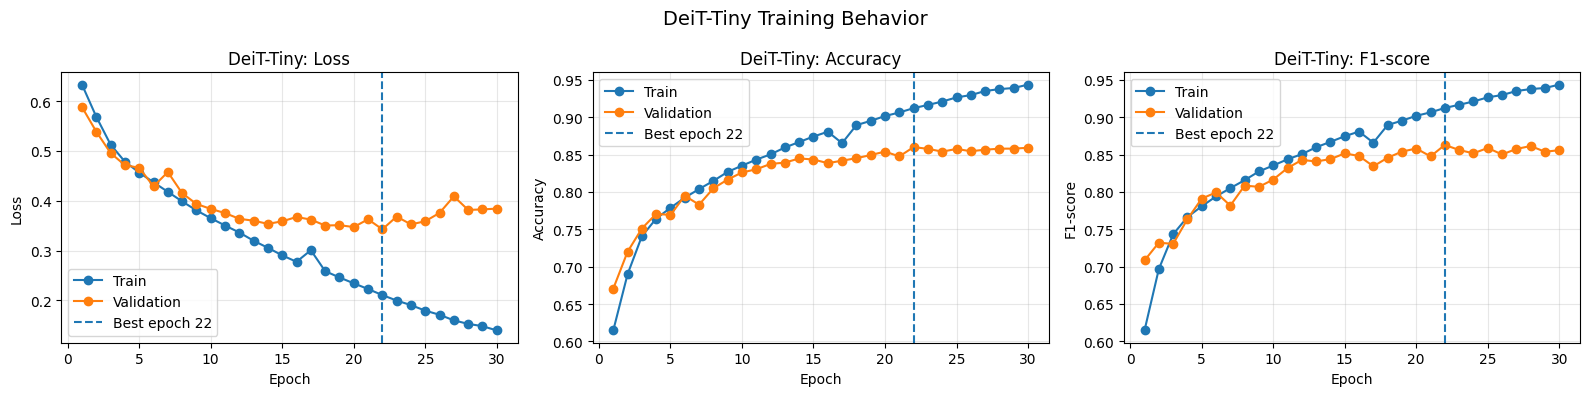

Saved figure to: /Users/tranquangtrong/Desktop/cifake-image-classification-explainable-ai/outputs/figures/training_behavior/deit_tiny_training_curves.png


In [13]:

plot_single_model_training_curves("DeiT-Tiny")

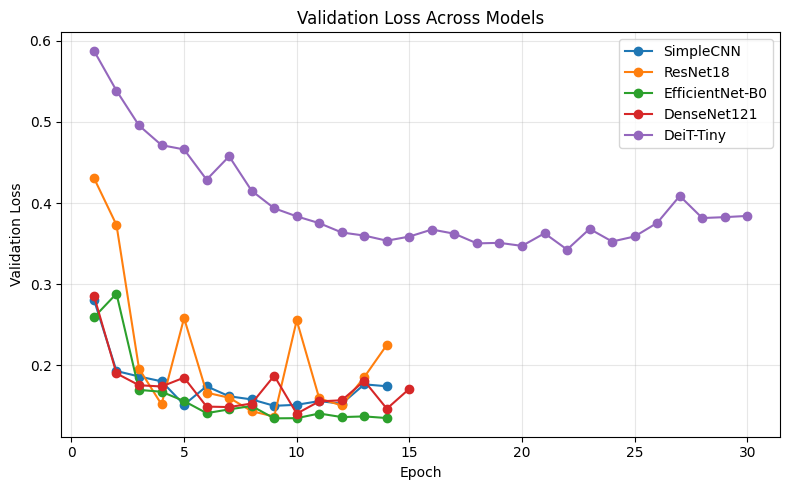

Saved figure to: /Users/tranquangtrong/Desktop/cifake-image-classification-explainable-ai/outputs/figures/training_behavior/cross_model_validation_loss.png


In [15]:
# Plot cross-model validation loss

plt.figure(figsize=(8, 5))

for model_name, df in history_by_model.items():
    plt.plot(df["epoch"], df["val_loss"], marker="o", label=model_name)

plt.title("Validation Loss Across Models")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

output_path = FIGURES_DIR / "cross_model_validation_loss.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {output_path}")

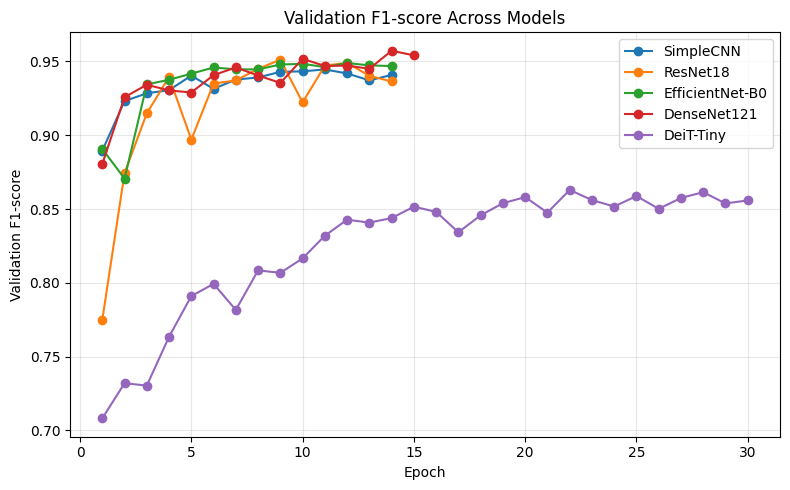

Saved figure to: /Users/tranquangtrong/Desktop/cifake-image-classification-explainable-ai/outputs/figures/training_behavior/cross_model_validation_f1.png


In [16]:
# Plot cross-model validation F1-score

plt.figure(figsize=(8, 5))

for model_name, df in history_by_model.items():
    plt.plot(df["epoch"], df["val_f1"], marker="o", label=model_name)

plt.title("Validation F1-score Across Models")
plt.xlabel("Epoch")
plt.ylabel("Validation F1-score")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

output_path = FIGURES_DIR / "cross_model_validation_f1.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {output_path}")

In [17]:

# Cell 6.1: Create final test results table for Chapter 6

test_results_df = metadata_df[
    [
        "model",
        "best_epoch",
        "test_loss",
        "test_accuracy",
        "test_precision",
        "test_recall",
        "test_f1",
    ]
].copy()

# Rank models by test F1-score first, then accuracy
test_results_df = test_results_df.sort_values(
    by=["test_f1", "test_accuracy"],
    ascending=False,
).reset_index(drop=True)

test_results_df.insert(0, "rank", range(1, len(test_results_df) + 1))

display(test_results_df)





,rank,model,best_epoch,test_loss,test_accuracy,test_precision,test_recall,test_f1
0,1,DenseNet121,10,0.136493,0.95120,0.944007,0.9593,0.951592
1,2,EfficientNet-B0,9,0.129921,0.94955,0.950045,0.9490,0.949522
2,3,ResNet18,9,0.137099,0.94800,0.941902,0.9549,0.948356
3,4,SimpleCNN,9,0.150262,0.94265,0.953117,0.9311,0.941980
4,5,DeiT-Tiny,22,0.336656,0.86115,0.848701,0.8790,0.863585


In [ ]:
# Save CSV for later use
test_results_path = ANALYSIS_DIR / "final_test_results_summary.csv"
test_results_df.to_csv(test_results_path, index=False)

print(f"Saved final test results to: {test_results_path}")

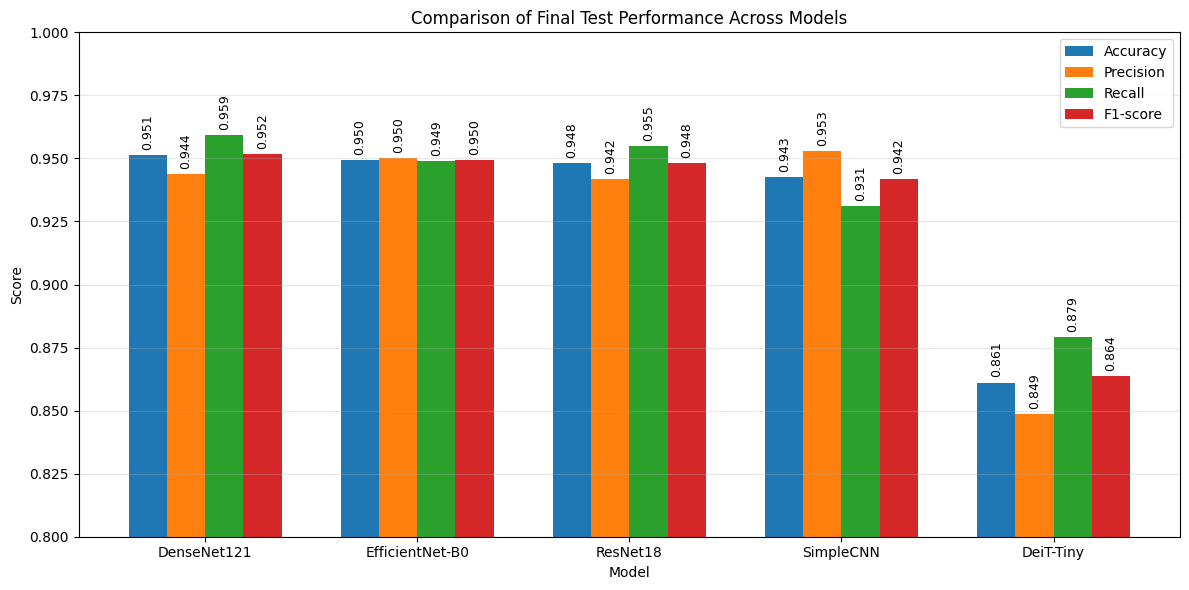

Saved figure to: /Users/tranquangtrong/Desktop/cifake-image-classification-explainable-ai/outputs/figures/results/comparison_models.png


In [18]:
# Cell 6.2: Create comparison figure for Chapter 6

import numpy as np
import matplotlib.pyplot as plt

RESULTS_FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures" / "results"
RESULTS_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plot_df = test_results_df.copy()

metric_columns = [
    "test_accuracy",
    "test_precision",
    "test_recall",
    "test_f1",
]

metric_labels = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
]

models = plot_df["model"].tolist()
x = np.arange(len(models))
bar_width = 0.18

fig, ax = plt.subplots(figsize=(12, 6))

for i, (col, label) in enumerate(zip(metric_columns, metric_labels)):
    values = plot_df[col].values
    bars = ax.bar(x + i * bar_width, values, width=bar_width, label=label)

    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.002,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
            rotation=90
        )

ax.set_title("Comparison of Final Test Performance Across Models")
ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_xticks(x + 1.5 * bar_width)
ax.set_xticklabels(models)
ax.set_ylim(0.80, 1.00)
ax.legend()
ax.grid(True, axis="y", alpha=0.3)

fig.tight_layout()

output_path = RESULTS_FIGURES_DIR / "comparison_models.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {output_path}")